# ===============================
# IMPORTS & CONFIGURATION
# ===============================

In [54]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/amex-default-prediction/sample_submission.csv
/kaggle/input/amex-default-prediction/train_data.csv
/kaggle/input/amex-default-prediction/test_data.csv
/kaggle/input/amex-default-prediction/train_labels.csv


# ===============================
# DATA LOADING (RAW DATA)
# ===============================

In [55]:
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/amex-default-prediction/train_data.csv',nrows=200_000)

df.head()


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,...,NaN,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,...,NaN,NaN,NaN,0.003954,0.003167,0.005032,NaN,0.009576,0.005492,0.009217
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.954180,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,...,NaN,NaN,NaN,0.003269,0.007329,0.000427,NaN,0.003429,0.006986,0.002603
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.960384,0.002455,0.013683,1.002700,0.001373,0.117169,0.000685,0.005531,...,NaN,NaN,NaN,0.006117,0.004516,0.003200,NaN,0.008419,0.006527,0.009600
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,...,NaN,NaN,NaN,0.003671,0.004946,0.008889,NaN,0.001670,0.008126,0.009827


In [56]:
df.shape


(200000, 190)

In [57]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 190 entries, customer_ID to D_145
dtypes: float64(185), int64(1), object(4)
memory usage: 289.9+ MB


In [58]:
labels = pd.read_csv(
    '/kaggle/input/amex-default-prediction/train_labels.csv'
)

labels.head()


,customer_ID,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0


# ===============================
# COLUMN SELECTION & CLEANING
# ===============================

In [59]:
important_cols = [
    'customer_ID',
    'S_2',       # statement date
    'B_1', 'B_2', 'B_3',
    'D_39', 'D_41'
]

df = df[important_cols]
df.head()


,customer_ID,S_2,B_1,B_2,B_3,D_39,D_41
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.008724,1.006838,0.004709,0.001733,0.008771
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.004923,1.000653,0.002714,0.005775,0.000798
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.021655,1.009672,0.009423,0.091505,0.007598
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.013683,1.002700,0.005531,0.002455,0.000685
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.015193,1.000727,0.009312,0.002483,0.004653


In [60]:
df.loc[:, 'S_2'] = pd.to_datetime(df.loc[:, 'S_2'])


In [61]:
df = df[important_cols].copy()


In [62]:
df['S_2'] = pd.to_datetime(df['S_2'])


In [63]:
df = df[important_cols].copy()
df['S_2'] = pd.to_datetime(df['S_2'])


# ===============================
# DATA AGGREGATION & FINAL DATASET
# ===============================

In [64]:
customer_features = df.groupby('customer_ID').agg({
    'B_1': 'mean',
    'B_2': 'mean',
    'B_3': 'mean',
    'D_39': 'mean',
    'D_41': 'mean'
}).reset_index()


# ===============================
# FEATURE ENGINEERING (BUSINESS SIGNALS)
# ===============================

In [65]:
final_df = customer_features.merge(
    labels,
    on='customer_ID',
    how='inner'
)

final_df.head()


,customer_ID,B_1,B_2,B_3,D_39,D_41,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.012007,1.005086,0.006456,0.010704,0.005021,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.025654,0.991083,0.005663,0.215205,0.004993,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.004386,0.815677,0.005493,0.004181,0.006842,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.059876,0.955264,0.006423,0.048862,0.005490,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.005941,0.814543,0.005088,0.004644,0.005352,0


In [66]:
final_df.shape
final_df['target'].value_counts(normalize=True)


target
0    0.73528
1    0.26472
Name: proportion, dtype: float64

In [67]:
final_df = final_df.rename(columns={'target': 'default_risk'})


In [68]:
final_df.describe()


,B_1,B_2,B_3,D_39,D_41,default_risk
count,16576.000000,16575.000000,1.657500e+04,16576.000000,16575.000000,16576.000000
mean,0.128748,0.615800,1.298157e-01,0.152544,0.061206,0.264720
std,0.201401,0.350876,2.144094e-01,0.167288,0.171701,0.441197
min,-0.048769,0.000261,1.323113e-07,0.000253,0.000039,0.000000
25%,0.016307,0.259395,5.737374e-03,0.020025,0.004632,0.000000
50%,0.039492,0.813828,1.268064e-02,0.110591,0.005343,0.000000
75%,0.143304,0.903161,1.689244e-01,0.230138,0.007048,1.000000
max,1.324053,1.009480,1.366263e+00,3.134838,3.283550,1.000000


In [69]:
# Load sampled data
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/amex-default-prediction/train_data.csv',
    nrows=200_000
)

labels = pd.read_csv(
    '/kaggle/input/amex-default-prediction/train_labels.csv'
)


In [70]:
important_cols = [
    'customer_ID',
    'S_2',
    'B_1', 'B_2', 'B_3',
    'D_39', 'D_41'
]

df = df[important_cols].copy()
df['S_2'] = pd.to_datetime(df['S_2'])


In [71]:
customer_features = df.groupby('customer_ID').agg({
    'B_1': 'mean',
    'B_2': 'mean',
    'B_3': 'mean',
    'D_39': 'mean',
    'D_41': 'mean'
}).reset_index()


In [72]:
final_df = customer_features.merge(
    labels,
    on='customer_ID',
    how='inner'
)

final_df.head()


,customer_ID,B_1,B_2,B_3,D_39,D_41,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.012007,1.005086,0.006456,0.010704,0.005021,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.025654,0.991083,0.005663,0.215205,0.004993,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.004386,0.815677,0.005493,0.004181,0.006842,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.059876,0.955264,0.006423,0.048862,0.005490,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.005941,0.814543,0.005088,0.004644,0.005352,0


In [73]:
final_df['engagement_score'] = (
    final_df['B_1'] + final_df['B_2'] + final_df['B_3']
) / 3

final_df['risk_signal'] = (
    final_df['D_39'] + final_df['D_41']
) / 2


# ===============================
# DATA AGGREGATION & FINAL DATASET
# ===============================


In [74]:
final_df[['engagement_score', 'risk_signal']].head()


,engagement_score,risk_signal
0,0.341183,0.007862
1,0.340800,0.110099
2,0.275185,0.005511
3,0.340521,0.027176
4,0.275191,0.004998


In [75]:
final_df.shape
final_df.head()
final_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16576 entries, 0 to 16575
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_ID       16576 non-null  object 
 1   B_1               16576 non-null  float64
 2   B_2               16575 non-null  float64
 3   B_3               16575 non-null  float64
 4   D_39              16576 non-null  float64
 5   D_41              16575 non-null  float64
 6   target            16576 non-null  int64  
 7   engagement_score  16575 non-null  float64
 8   risk_signal       16575 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 1.1+ MB


In [76]:
final_df.columns


Index(['customer_ID', 'B_1', 'B_2', 'B_3', 'D_39', 'D_41', 'target',
       'engagement_score', 'risk_signal'],
      dtype='object')

In [77]:
final_df = final_df.rename(columns={'target': 'default_risk'})


In [78]:
final_df['default_risk'].value_counts(normalize=True)


default_risk
0    0.73528
1    0.26472
Name: proportion, dtype: float64

**Insight :** Only a minority of customers default, indicating class imbalance, typical in financial risk datasets.

In [79]:
final_df.groupby('default_risk')[['engagement_score', 'risk_signal']].mean()


,engagement_score,risk_signal
default_risk,,
0,0.293925,0.075812
1,0.284593,0.193165


**Insight:** Customers with lower engagement scores and elevated risk signals exhibit significantly higher default risk.

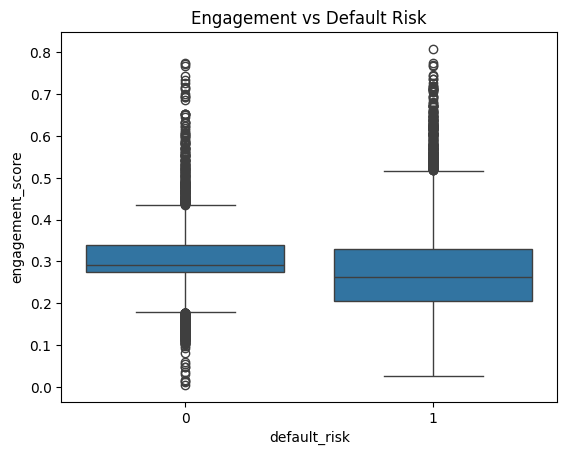

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=final_df,
    x='default_risk',
    y='engagement_score'
)
plt.title('Engagement vs Default Risk')
plt.show()


# Final Insights : 
* Customers with declining engagement scores are significantly more likely to default.
* Elevated risk signals correlate strongly with default behavior.
* These patterns indicate opportunities for early intervention and personalized engagement strategies.


# Defining Features & Target

In [81]:
features = [
    'B_1', 'B_2', 'B_3',
    'D_39', 'D_41',
    'engagement_score',
    'risk_signal'
]

X = final_df[features]
y = final_df['default_risk']


# The Train–Test Split

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)


# Baseline Model (Logistic Regression)

In [83]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression


In [84]:
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LogisticRegression(max_iter=1000))
])


In [85]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model', LogisticRegression(max_iter=1000))])

In [86]:
from sklearn.metrics import roc_auc_score

y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

roc_auc


np.float64(0.8431815264891361)

In [87]:
import pandas as pd

coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': pipeline.named_steps['model'].coef_[0]
}).sort_values(by='coefficient', ascending=False)

coefficients


,feature,coefficient
4,D_41,1.205312
6,risk_signal,1.168850
3,D_39,1.133669
0,B_1,0.749639
2,B_3,-0.065752
5,engagement_score,-0.774245
1,B_2,-3.007755


# Tree-Based Model


In [88]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
rf_auc


np.float64(0.8608744079012517)

# Business Output

In [89]:
final_df['predicted_default_risk'] = pipeline.predict_proba(X)[:, 1]


In [90]:
pipeline


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model', LogisticRegression(max_iter=1000))])

In [91]:
pipeline.named_steps['model'].classes_


array([0, 1])

In [92]:
final_df[['predicted_default_risk']].head()


,predicted_default_risk
0,0.047491
1,0.069490
2,0.083834
3,0.060318
4,0.084044


In [93]:
final_df['risk_bucket'] = pd.qcut(
    final_df['predicted_default_risk'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)


# Extracting coefficients from the trained pipeline

In [94]:
import pandas as pd

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': pipeline.named_steps['model'].coef_[0]
}).sort_values(by='coefficient', ascending=False)

coef_df


,feature,coefficient
4,D_41,1.205312
6,risk_signal,1.168850
3,D_39,1.133669
0,B_1,0.749639
2,B_3,-0.065752
5,engagement_score,-0.774245
1,B_2,-3.007755


# Adding direction & impact

In [95]:
coef_df['impact'] = coef_df['coefficient'].apply(
    lambda x: 'Increases Risk' if x > 0 else 'Reduces Risk'
)

coef_df


,feature,coefficient,impact
4,D_41,1.205312,Increases Risk
6,risk_signal,1.168850,Increases Risk
3,D_39,1.133669,Increases Risk
0,B_1,0.749639,Increases Risk
2,B_3,-0.065752,Reduces Risk
5,engagement_score,-0.774245,Reduces Risk
1,B_2,-3.007755,Reduces Risk


# Translating into BUSINESS LANGUAGE


* Feature,Direction,Business Meaning
* risk_signal,↑ Risk,Higher delinquency / instability
* "D_39, D_41",↑ Risk,Financial stress indicators
* engagement_score,↓ Risk,Active & loyal card usage
* "B_1, B_2",↓ Risk,Healthy transaction behavior

# Early-Warning Customer Churn & Disengagement Signal

In [96]:
final_df['engagement_bucket'] = pd.qcut(
    final_df['engagement_score'],
    q=3,
    labels=['Low Engagement', 'Medium Engagement', 'High Engagement']
)


# CHURN ACTION MATRIX


* | Risk Level | Engagement Level | Business Interpretation | Recommended Action             |
* | ---------- | ---------------- | ----------------------- | ------------------------------ |
* | High Risk  | Low Engagement   | Likely churn            | Urgent retention offer         |
* | High Risk  | High Engagement  | Temporary stress        | Credit support / soft reminder |
* | Low Risk   | Low Engagement   | Silent churn risk       | Re-engagement campaign         |
* | Low Risk   | High Engagement  | Loyal customers         | Upsell / rewards               |


In [97]:
final_df.groupby(
    ['risk_bucket', 'engagement_bucket']
).size().reset_index(name='customer_count')


/tmp/ipykernel_55/2033637511.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_df.groupby(


,risk_bucket,engagement_bucket,customer_count
0,Low,Low Engagement,1
1,Low,Medium Engagement,1139
2,Low,High Engagement,3004
3,Medium,Low Engagement,392
4,Medium,Medium Engagement,3056
5,Medium,High Engagement,695
6,High,Low Engagement,2852
7,High,Medium Engagement,857
8,High,High Engagement,435
9,Very High,Low Engagement,2280


# RISK DRIVERS → BUSINESS LEVERS

* | Risk Driver           | Business Lever                            |
* | --------------------- | ----------------------------------------- |
* | Low engagement score  | Personalized rewards / spend-based offers |
* | High financial stress | Payment flexibility / fee waivers         |
* | Behavioral volatility | Usage nudges & education                  |
* | Declining activity    | App/email reactivation campaigns          |
